# Perfect Detector Timing Analysis

This notebook analyzes time-resolved collision tracking data from a fixed-source simulation with a **perfect spherical detector shell** surrounding the core. Key analyses include:

- **Time-binned histograms**: Logarithmic binning to capture multi-decade time distributions
- **Sibling multiplicity**: Distribution of neutrons detected from the same parent particle
- **Validation**: Checking that first detections are physically possible
- **Fission statistics**: Extracting fission counts from tally data

**Note**: The perfect detector geometry captures all neutrons escaping the core, providing 100% geometric efficiency.

## Setup and Imports

In [1]:
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import openmc
import pandas as pd
import scienceplots

from project.core.geometry import DEFAULTS

# Configure plotting style
plt.style.use(["science", "notebook", "grid", "high-vis"])

# Output directories
FIGURES_DIR = Path("../outputs/figures")
DATA_DIR = Path("../outputs/data")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load Collision Track Data

Load the collision track HDF5 file and convert to a pandas DataFrame for analysis.

In [ ]:
# Load collision track file
collision_file = Path("../../results/simulation_with_perfect_detector/collision_track.h5")
data: Any = openmc.read_collision_track_file(str(collision_file))

# Convert to DataFrame
df = pd.DataFrame(
    {
        "r_x": data["r"]["x"],
        "r_y": data["r"]["y"],
        "r_z": data["r"]["z"],
        "u_x": data["u"]["x"],
        "u_y": data["u"]["y"],
        "u_z": data["u"]["z"],
        "E": data["E"],
        "dE": data["dE"],
        "time": data["time"],
        "wgt": data["wgt"],
        "event_mt": data["event_mt"],
        "delayed_group": data["delayed_group"],
        "cell_id": data["cell_id"],
        "nuclide_id": data["nuclide_id"],
        "material_id": data["material_id"],
        "universe_id": data["universe_id"],
        "n_collision": data["n_collision"],
        "particle": data["particle"],
        "parent_id": data["parent_id"],
        "progeny_id": data["progeny_id"],
    }
)

print(f"Total collision events: {len(df):,}")
df.head()


Total collision events: 21,670,502


In [3]:
# Extract detector collision times (cell_id == 2 is the detector)
DETECTOR_CELL_ID = 2
detector_times = df[df["cell_id"] == DETECTOR_CELL_ID]["time"].values

print(f"Detector collisions: {len(detector_times):,}")
print(f"Time range: {detector_times.min():.2e} - {detector_times.max():.2e} s")

Detector collisions: 21,670,502
Time range: 1.23e-08 - 7.41e+02 s


## Time-Binned Histogram Analysis

Create logarithmically-spaced bins to capture the multi-decade time distribution of detector events.

In [4]:
# Prepare data: remove non-positive and non-finite values
times_clean = detector_times[np.isfinite(detector_times) & (detector_times > 0)]

if times_clean.size == 0:
    raise ValueError("No valid positive timestamps found for histogram")

# Create logarithmic bins
N_BINS = 256
log_edges = np.logspace(
    np.log10(times_clean.min()), np.log10(times_clean.max()), N_BINS + 1
)

# Compute histogram
counts, edges = np.histogram(times_clean, bins=log_edges)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = edges[1:] - edges[:-1]

# Store in DataFrame for analysis and export
hist_df = pd.DataFrame(
    {
        "count": counts,
        "density": counts / bin_widths,
        "left_edge": edges[:-1],
        "right_edge": edges[1:],
        "center": bin_centers,
        "width": bin_widths,
    }
)

print(f"Created {N_BINS} logarithmic bins")
hist_df.head()

Created 256 logarithmic bins


,count,density,left_edge,right_edge,center,width
0,1,7.980076e+08,1.230770e-08,1.356082e-08,1.293426e-08,1.253121e-09
1,3,2.172797e+09,1.356082e-08,1.494153e-08,1.425118e-08,1.380709e-09
2,9,5.916044e+09,1.494153e-08,1.646282e-08,1.570217e-08,1.521287e-09
3,6,3.579572e+09,1.646282e-08,1.813900e-08,1.730091e-08,1.676178e-09
4,8,4.331723e+09,1.813900e-08,1.998584e-08,1.906242e-08,1.846840e-09


### Visualize Time Distributions

Plot histograms with different scale combinations to reveal structure at different timescales.

In [5]:
def plot_histogram(centers, values, widths, xscale, yscale, ylabel, title, filename):
    """Helper function to create consistent histogram plots."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)
    ax.bar(centers, values, width=widths, align="center", edgecolor="k", alpha=0.8)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    return fig, ax

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Perfect Detector Arrival Times (Log-Linear)'}, xlabel='Time (s)', ylabel='Counts'>)

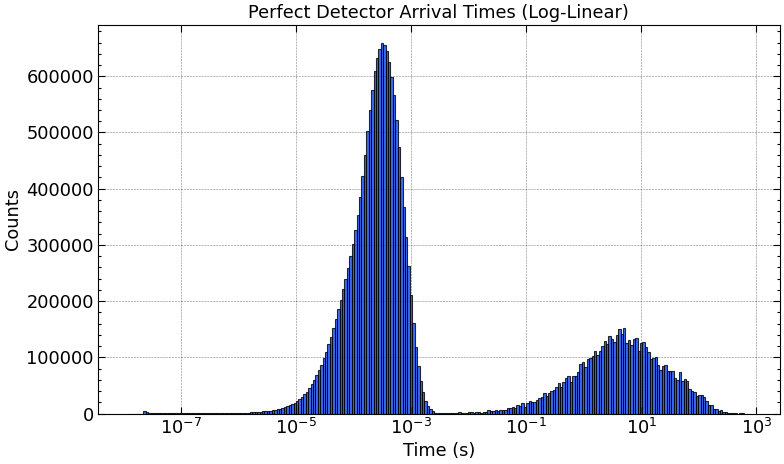

In [6]:
# Count histogram: log-linear
plot_histogram(
    bin_centers,
    counts,
    bin_widths,
    xscale="log",
    yscale="linear",
    ylabel="Counts",
    title="Perfect Detector Arrival Times (Log-Linear)",
    filename="perfect_detector_histogram_log_linear.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Perfect Detector Arrival Times (Log-Log)'}, xlabel='Time (s)', ylabel='Counts'>)

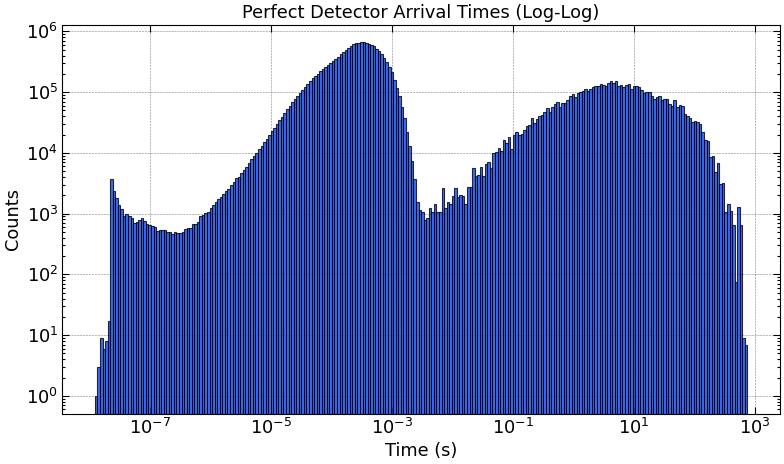

In [7]:
# Count histogram: log-log
plot_histogram(
    bin_centers,
    counts,
    bin_widths,
    xscale="log",
    yscale="log",
    ylabel="Counts",
    title="Perfect Detector Arrival Times (Log-Log)",
    filename="perfect_detector_histogram_log_log.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Perfect Detector Arrival Rate (Log-Linear)'}, xlabel='Time (s)', ylabel='Counts per Unit Time'>)

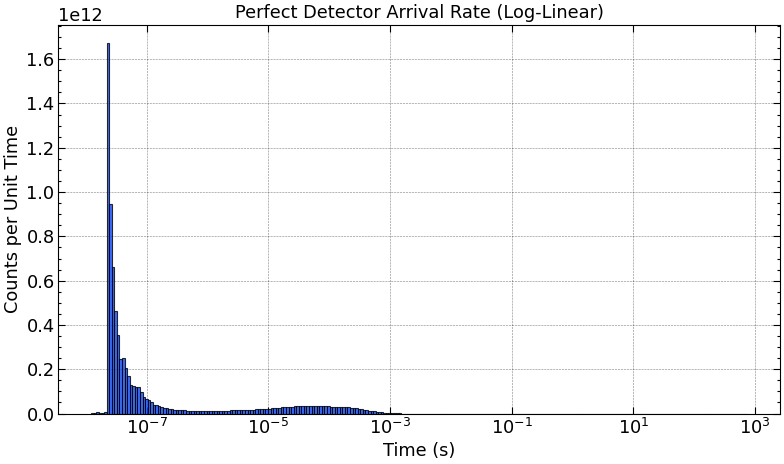

In [8]:
# Density histogram: log-linear
plot_histogram(
    bin_centers,
    counts / bin_widths,
    bin_widths,
    xscale="log",
    yscale="linear",
    ylabel="Counts per Unit Time",
    title="Perfect Detector Arrival Rate (Log-Linear)",
    filename="perfect_detector_density_histogram_log_linear.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Perfect Detector Arrival Rate (Log-Log)'}, xlabel='Time (s)', ylabel='Counts per Unit Time'>)

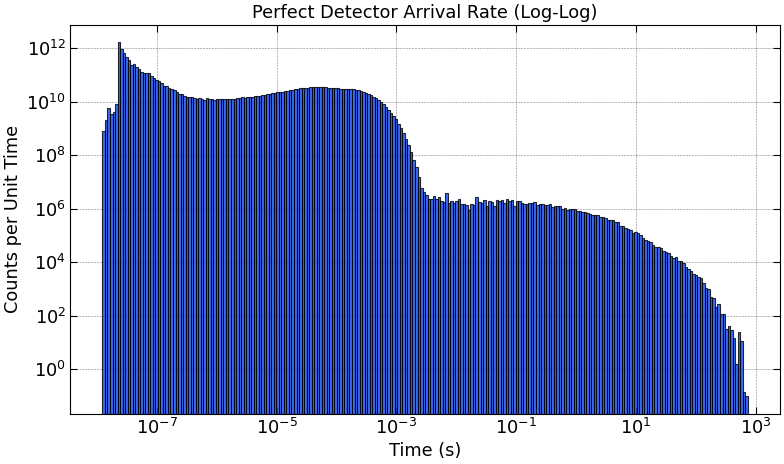

In [9]:
# Density histogram: log-log
plot_histogram(
    bin_centers,
    counts / bin_widths,
    bin_widths,
    xscale="log",
    yscale="log",
    ylabel="Counts per Unit Time",
    title="Perfect Detector Arrival Rate (Log-Log)",
    filename="perfect_detector_density_histogram_log_log.png",
)

### Export Binned Data

In [10]:
# Export histogram data to Excel
output_file = DATA_DIR / "perfect_detector_collision_track_binned.xlsx"
hist_df.to_excel(output_file, index=False)
print(f"Saved {len(hist_df)} bins to {output_file}")

Saved 256 bins to ../outputs/data/perfect_detector_collision_track_binned.xlsx


## Sibling Multiplicity Analysis

Analyze how many neutrons from the same parent particle reach the detector. This reveals correlations in the neutron transport process.

In [11]:
def calculate_sibling_multiplicity(parent_ids):
    """
    Calculate the distribution of detection multiplicities per parent particle.

    Parameters
    ----------
    parent_ids : array-like
        Parent ID for each detected neutron

    Returns
    -------
    multiplicities : np.ndarray
        Array [1, 2, 3, ...] up to max observed
    counts : np.ndarray
        How many parents had each multiplicity
    stats : dict
        Summary statistics
    """
    # Count detections per parent
    detections_per_parent = Counter(parent_ids)

    # Count parents with each multiplicity
    multiplicity_dist = Counter(detections_per_parent.values())

    # Create arrays
    max_multiplicity = max(multiplicity_dist.keys())
    multiplicities = np.arange(1, max_multiplicity + 1)
    counts = np.array([multiplicity_dist.get(m, 0) for m in multiplicities])

    # Calculate statistics
    total_parents = counts.sum()
    total_detections = (multiplicities * counts).sum()
    mean_multiplicity = total_detections / total_parents if total_parents > 0 else 0

    stats = {
        "total_parents": int(total_parents),
        "total_detections": int(total_detections),
        "mean_multiplicity": float(mean_multiplicity),
        "max_multiplicity": int(max_multiplicity),
    }

    return multiplicities, counts, stats

In [12]:
# Extract parent IDs for detector events
detector_parent_ids = df[df["cell_id"] == DETECTOR_CELL_ID]["parent_id"].values

# Calculate sibling multiplicity
multiplicities, mult_counts, mult_stats = calculate_sibling_multiplicity(
    detector_parent_ids
)

print("\nSibling Multiplicity Statistics:")
print(f"  Total parent particles: {mult_stats['total_parents']:,}")
print(f"  Total detections: {mult_stats['total_detections']:,}")
print(f"  Mean multiplicity: {mult_stats['mean_multiplicity']:.3f}")
print(f"  Max multiplicity: {mult_stats['max_multiplicity']}")


Sibling Multiplicity Statistics:
  Total parent particles: 544,076
  Total detections: 21,670,502
  Mean multiplicity: 39.830
  Max multiplicity: 12614


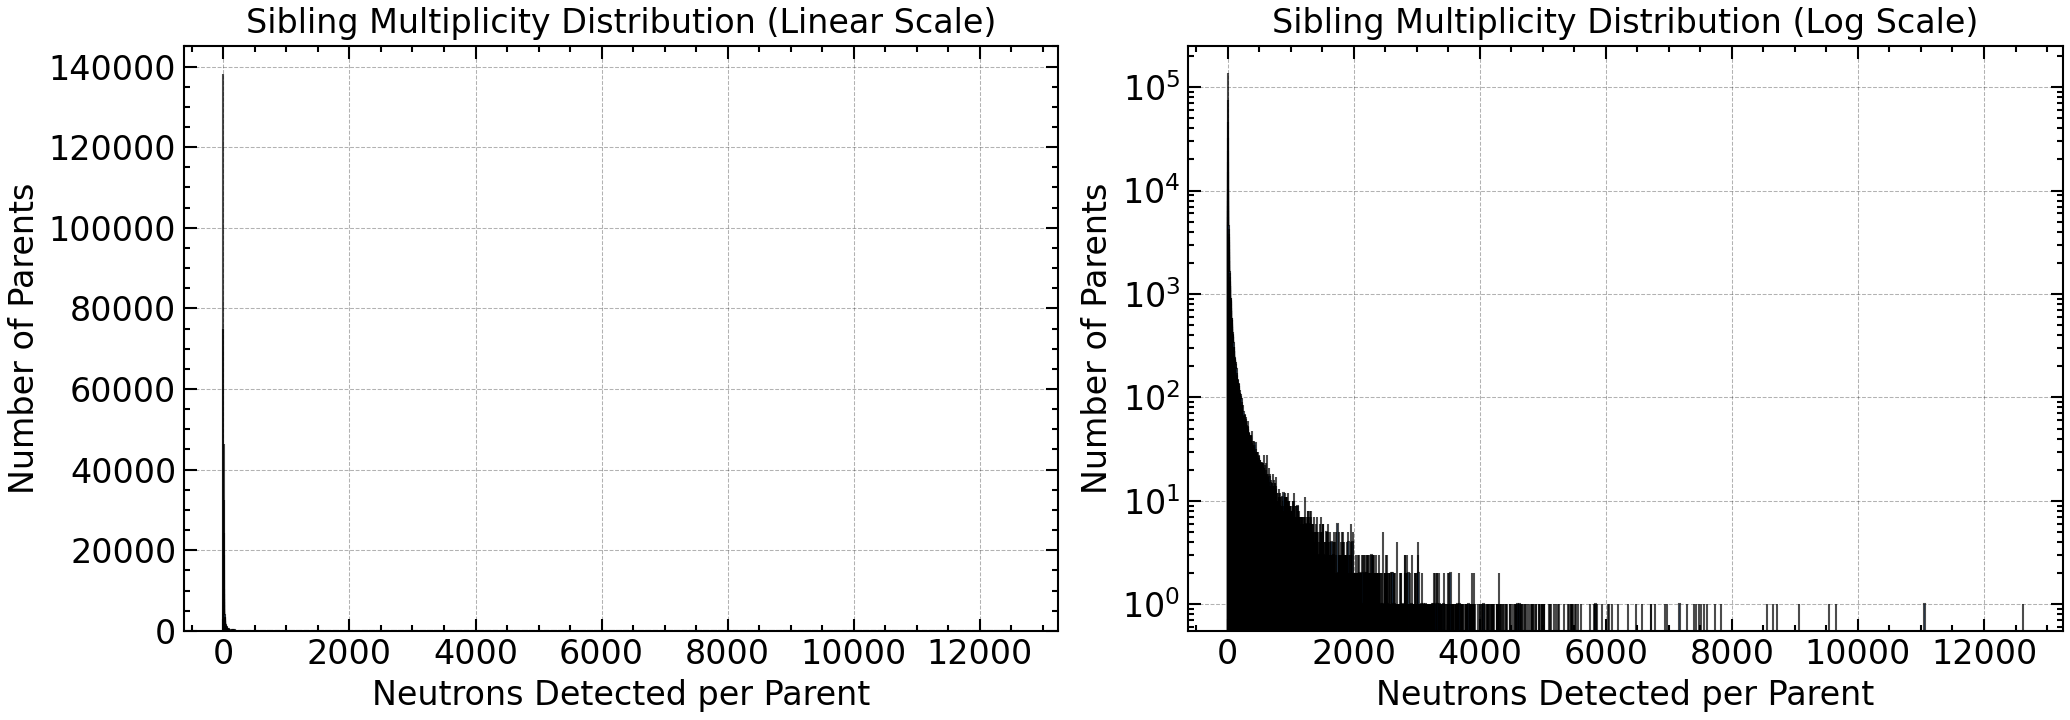

In [13]:
# Plot sibling multiplicity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Linear scale
axes[0].bar(multiplicities, mult_counts, edgecolor="black", alpha=0.7, color="#4A90E2")
axes[0].set_xlabel("Neutrons Detected per Parent")
axes[0].set_ylabel("Number of Parents")
axes[0].set_title("Sibling Multiplicity Distribution (Linear Scale)")
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].bar(multiplicities, mult_counts, edgecolor="black", alpha=0.7, color="#4A90E2")
axes[1].set_xlabel("Neutrons Detected per Parent")
axes[1].set_ylabel("Number of Parents")
axes[1].set_yscale("log")
axes[1].set_title("Sibling Multiplicity Distribution (Log Scale)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "perfect_detector_sibling_multiplicity.png", dpi=300, bbox_inches="tight")
plt.show()

### Calculate Total Correlated Pairs

Compute the total number of pairs of neutrons from the same parent. This is relevant for coincidence counting applications.

In [14]:
# Calculate total pairs: for multiplicity n, there are n*(n-1)/2 pairs
total_pairs = sum(
    int(mult_counts[n - 1]) * n * (n - 1) // 2 for n in range(2, len(mult_counts) + 1)
)

print(f"\nTotal correlated pairs of detected neutrons: {total_pairs:,}")


Total correlated pairs of detected neutrons: 9,832,685,511


## Physical Validation

Verify that the earliest detector event is physically possible given the geometry and source energy.

**Note**: For the perfect detector shell, the minimum distance is from the source to the inner edge of the detector shell (outer edge of core).

In [15]:
# Get first detection time
first_detection = float(detector_times.min())

# Calculate minimum flight distance for perfect detector shell
# Perfect detector starts at the core radius (inner edge of shell)
core_radius = DEFAULTS["core_radius"]  # cm
distance_to_detector = core_radius  # cm (source at origin, detector shell at core radius)
distance_meters = distance_to_detector * 0.01  # m

# Calculate neutron velocity from source energy (2.5 MeV)
E_eV = 2.5e6  # eV
E_J = E_eV * 1.60218e-19  # Joules
m_neutron = 1.67493e-27  # kg
v_neutron = np.sqrt(2 * E_J / m_neutron)  # m/s

# Minimum flight time
min_flight_time = distance_meters / v_neutron  # s

# Implied source emission time
implied_source_time = first_detection - min_flight_time

print("\nPhysical Validation of First Detection:")
print(f"  First detection time: {first_detection:.3e} s")
print(f"  Distance to detector shell: {distance_meters:.3f} m")
print(f"  Neutron velocity (2.5 MeV): {v_neutron:.3e} m/s")
print(f"  Minimum flight time: {min_flight_time:.3e} s")
print(f"  Implied source time: {implied_source_time:.3e} s")

if implied_source_time < 0:
    print("\n⚠️  WARNING: Negative source time - physically impossible!")
else:
    print("\n✓ Validation passed: First detection is physically consistent")


Physical Validation of First Detection:
  First detection time: 1.231e-08 s
  Distance to detector shell: 0.030 m
  Neutron velocity (2.5 MeV): 2.187e+07 m/s
  Minimum flight time: 1.372e-09 s
  Implied source time: 1.094e-08 s

✓ Validation passed: First detection is physically consistent


## Fission Statistics

Extract fission rate per source neutron from the tally data.

In [16]:
# Load statepoint file
statepoint_file = Path("../../results/simulation_with_perfect_detector/statepoint.1.h5")
sp = openmc.StatePoint(str(statepoint_file))

# Extract fission tally (ID=1)
tally = sp.get_tally(id=1)
fissions_per_source = tally.mean.flatten()[0]

print(f"\nFission Statistics:")
print(f"  Fissions per source neutron: {fissions_per_source:.2f}")


Fission Statistics:
  Fissions per source neutron: 37.64


## Summary

This analysis provided insights into the perfect detector shell geometry:
- **Temporal distribution**: Multi-decade time response captured in log-binned histograms
- **Correlations**: Sibling multiplicity shows parent-progeny detection patterns
- **Validation**: First detection times are physically consistent with geometry
- **Multiplication**: Fission rate quantifies neutron multiplication in the system
- **Perfect detection**: Shell geometry provides 100% geometric efficiency for neutrons escaping the core